# Benchmark Analysis\nCompare lookup and insert throughput for BTree, DynamicPGM, and LIPP across three datasets (fb, osmc, books).

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

tasks = ['fb', 'osmc', 'books']
indexs = ['BTree', 'DynamicPGM', 'LIPP']

# Load all result CSVs
data = {}
for task in tasks:
    name = f"{task}_100M_public_uint64"
    data[task] = {
        'lookup_only': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.000000i_results_table.csv"),
        'insert_lookup': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.500000i_0m_results_table.csv"),
        'mix_10': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.100000i_0m_mix_results_table.csv"),
        'mix_90': pd.read_csv(f"results/{name}_ops_2M_0.000000rq_0.500000nl_0.900000i_0m_mix_results_table.csv"),
    }
print("Loaded all results.")

Loaded all results.


In [30]:
def best_throughput(df, index_name, cols):
    """Get the best average throughput for a given index (best across search methods)."""
    rows = df[df['index_name'] == index_name]
    if rows.empty:
        return 0
    return rows[cols].mean(axis=1).max()

def best_search_method(df, index_name, cols):
    """Get the search method + value that gives the best average throughput."""
    rows = df[df['index_name'] == index_name]
    if rows.empty:
        return ""
    avg = rows[cols].mean(axis=1)
    best_idx = avg.idxmax()
    row = rows.loc[best_idx]
    method = row.get('search_method', '')
    value = row.get('value', '')
    if pd.isna(method) or method == '':
        return ""
    return f"{method}({int(value)})" if not pd.isna(value) else str(method)

def build_throughput_table(data_key, cols):
    """Build throughput DataFrame (index=indexs, columns=tasks) and search methods dict."""
    tp = pd.DataFrame({
        task: {idx: best_throughput(data[task][data_key], idx, cols) for idx in indexs}
        for task in tasks
    })
    methods = {
        idx: {task: best_search_method(data[task][data_key], idx, cols) for task in tasks}
        for idx in indexs
    }
    return tp, methods

def plot_throughput(tp, methods, title):
    """Plot grouped bar chart (grouped by index) with search method labels on bars."""
    fig, ax = plt.subplots(figsize=(9, 5))
    tp.plot(kind='bar', ax=ax)
    ax.set_ylabel('Throughput (Mops/s)')
    ax.set_title(title)
    ax.set_xticklabels(indexs, rotation=0)
    ax.legend(title='Dataset')
    y_max = ax.get_ylim()[1]

    # Annotate each bar with the search method
    for container_idx, task in enumerate(tasks):
        for bar_idx, (idx, bar) in enumerate(zip(indexs, ax.containers[container_idx])):
            label = methods.get(idx, {}).get(task, '')
            if not label:
                continue
            bar_height = bar.get_height()
            bar_x = bar.get_x() + bar.get_width() / 2
            # If bar is tall enough, place text inside; otherwise above
            if bar_height > y_max * 0.35:
                ax.text(bar_x, bar_height * 0.5, label,
                        ha='center', va='center', rotation=90,
                        fontsize=12, color='white', fontweight='bold')
            else:
                ax.text(bar_x, bar_height + y_max * 0.01, label,
                        ha='center', va='bottom', rotation=90,
                        fontsize=12, color='black')

    plt.tight_layout()
    plt.show()

lookup_cols = ['lookup_throughput_mops1', 'lookup_throughput_mops2', 'lookup_throughput_mops3']
insert_cols = ['insert_throughput_mops1', 'insert_throughput_mops2', 'insert_throughput_mops3']
mixed_cols = ['mixed_throughput_mops1', 'mixed_throughput_mops2', 'mixed_throughput_mops3']

lookuponly, lookuponly_m = build_throughput_table('lookup_only', lookup_cols)
insert_tp, insert_tp_m = build_throughput_table('insert_lookup', insert_cols)
lookup_after_insert, lookup_after_insert_m = build_throughput_table('insert_lookup', lookup_cols)
mix10, mix10_m = build_throughput_table('mix_10', mixed_cols)
mix90, mix90_m = build_throughput_table('mix_90', mixed_cols)

print("Throughput tables computed.")

Throughput tables computed.


## Lookup-only Throughput

                  fb      osmc     books
BTree       1.335130  1.632217  1.345377
DynamicPGM  1.714490  1.770237  1.814090
LIPP        6.184943  4.736100  6.578850



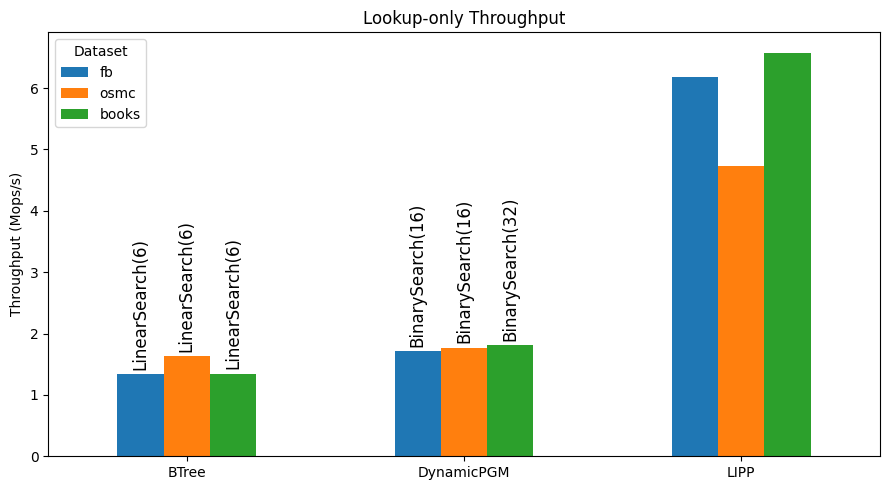

In [31]:
print(lookuponly.to_string())
print()
plot_throughput(lookuponly, lookuponly_m, 'Lookup-only Throughput')

## Insert Throughput (from 50% insert workload)

                  fb      osmc     books
BTree       0.852305  0.864013  0.839454
DynamicPGM  6.773250  5.899373  6.565857
LIPP        1.903527  1.501653  2.635157



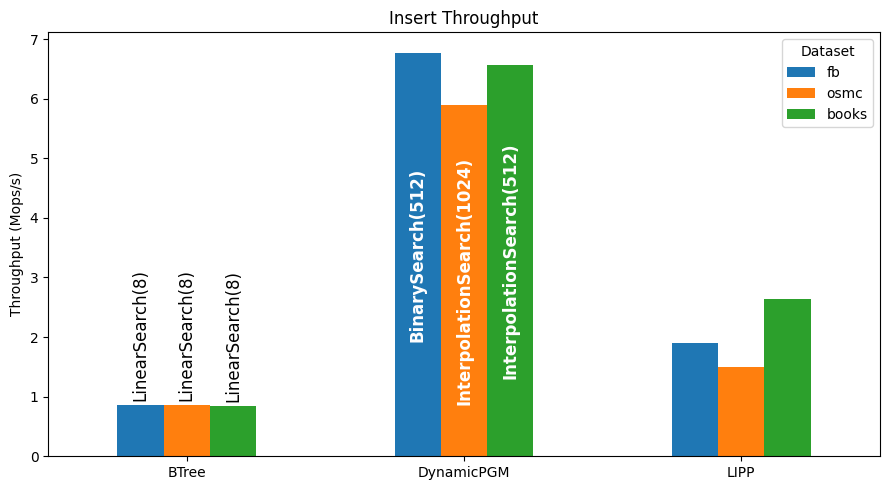

In [32]:
print(insert_tp.to_string())
print()
plot_throughput(insert_tp, insert_tp_m, 'Insert Throughput')

## Lookup Throughput after Inserts (from 50% insert workload)

                  fb      osmc     books
BTree       1.050183  1.433433  1.182277
DynamicPGM  0.437162  0.466533  0.542251
LIPP        5.933027  4.716890  6.388553



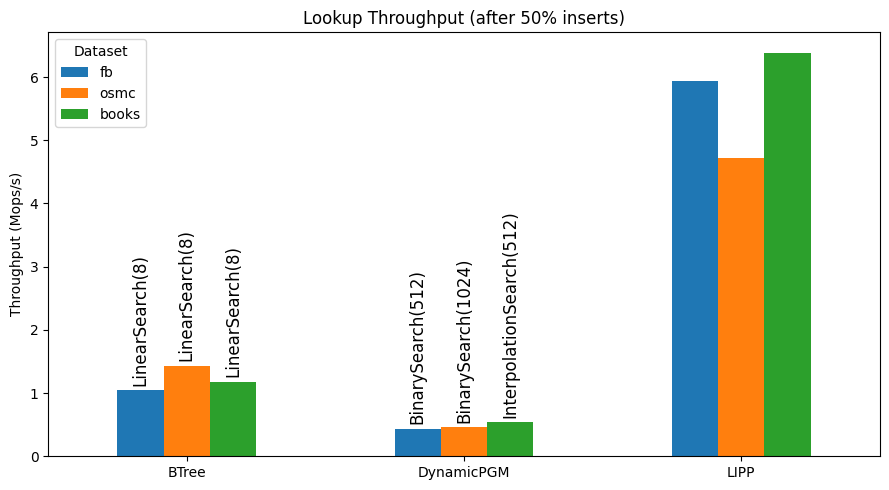

In [33]:
print(lookup_after_insert.to_string())
print()
plot_throughput(lookup_after_insert, lookup_after_insert_m, 'Lookup Throughput (after 50% inserts)')

## Mixed Workload - 10% Insert Ratio

                  fb      osmc     books
BTree       1.157410  1.331340  1.167303
DynamicPGM  0.890964  0.981918  0.936735
LIPP        5.166000  3.911227  5.415953



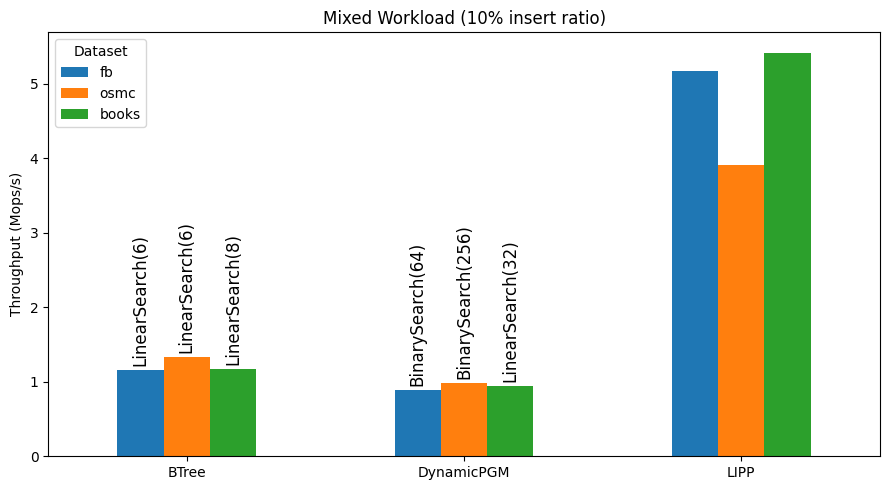

In [34]:
print(mix10.to_string())
print()
plot_throughput(mix10, mix10_m, 'Mixed Workload (10% insert ratio)')

## Mixed Workload - 90% Insert Ratio

                  fb      osmc     books
BTree       0.879591  0.887080  0.836897
DynamicPGM  2.975293  2.795763  2.934017
LIPP        2.036520  1.722433  2.769083



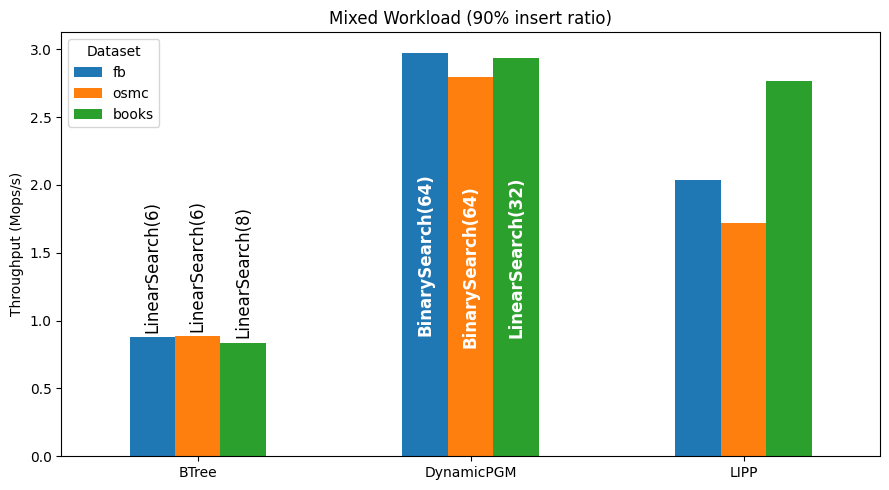

In [35]:
print(mix90.to_string())
print()
plot_throughput(mix90, mix90_m, 'Mixed Workload (90% insert ratio)')